In [1]:
!pip install torch torchvision matplotlib

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [3]:
transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

100%|██████████| 170M/170M [00:15<00:00, 11.2MB/s]


In [4]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

In [5]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = PrunableLinear(3072, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

In [6]:
def sparsity_loss(model):
    loss = 0
    for m in model.modules():
        if isinstance(m, PrunableLinear):
            gates = torch.sigmoid(m.gate_scores)
            loss += gates.sum()
    return loss

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
def train_model(lambda_val):
    model = Net().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(5):  # keep small for speed
        model.train()
        total_loss = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            ce_loss = criterion(outputs, labels)
            sp_loss = sparsity_loss(model)

            loss = ce_loss + lambda_val * sp_loss
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Lambda {lambda_val} | Epoch {epoch+1} | Loss: {total_loss:.2f}")

    return model

In [9]:
def evaluate(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [10]:
def compute_sparsity(model, threshold=1e-2):
    total = 0
    zero = 0

    for m in model.modules():
        if isinstance(m, PrunableLinear):
            gates = torch.sigmoid(m.gate_scores)
            total += gates.numel()
            zero += (gates < threshold).sum().item()

    return 100 * zero / total

In [11]:
lambdas = [0.0001, 0.001, 0.01]
results = []

for lam in lambdas:
    model = train_model(lam)
    acc = evaluate(model)
    sparsity = compute_sparsity(model)

    print(f"Lambda: {lam}, Accuracy: {acc:.2f}, Sparsity: {sparsity:.2f}%")
    results.append((lam, acc, sparsity))

Lambda 0.0001 | Epoch 1 | Loss: 31457.32
Lambda 0.0001 | Epoch 2 | Loss: 26177.60
Lambda 0.0001 | Epoch 3 | Loss: 21372.33
Lambda 0.0001 | Epoch 4 | Loss: 17212.30
Lambda 0.0001 | Epoch 5 | Loss: 13786.72
Lambda: 0.0001, Accuracy: 45.58, Sparsity: 0.07%
Lambda 0.001 | Epoch 1 | Loss: 307935.38
Lambda 0.001 | Epoch 2 | Loss: 255564.91
Lambda 0.001 | Epoch 3 | Loss: 207297.58
Lambda 0.001 | Epoch 4 | Loss: 165209.40
Lambda 0.001 | Epoch 5 | Loss: 130378.63
Lambda: 0.001, Accuracy: 42.92, Sparsity: 0.08%
Lambda 0.01 | Epoch 1 | Loss: 3068006.23
Lambda 0.01 | Epoch 2 | Loss: 2545228.26
Lambda 0.01 | Epoch 3 | Loss: 2063123.57
Lambda 0.01 | Epoch 4 | Loss: 1642686.07
Lambda 0.01 | Epoch 5 | Loss: 1294714.81
Lambda: 0.01, Accuracy: 43.03, Sparsity: 0.08%


In [12]:
def plot_gates(model):
    all_gates = []

    for m in model.modules():
        if isinstance(m, PrunableLinear):
            gates = torch.sigmoid(m.gate_scores).detach().cpu().numpy().flatten()
            all_gates.extend(gates)

    plt.hist(all_gates, bins=50)
    plt.title("Gate Value Distribution")
    plt.show()

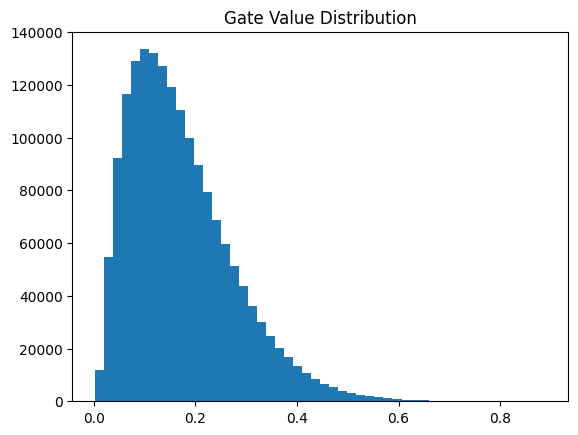

In [13]:
plot_gates(model)

In [14]:
for r in results:
    print(f"Lambda: {r[0]} | Accuracy: {r[1]:.2f} | Sparsity: {r[2]:.2f}%")

Lambda: 0.0001 | Accuracy: 45.58 | Sparsity: 0.07%
Lambda: 0.001 | Accuracy: 42.92 | Sparsity: 0.08%
Lambda: 0.01 | Accuracy: 43.03 | Sparsity: 0.08%


In [15]:
results_dict = []

lambdas = [0.0001, 0.001, 0.01]

for lam in lambdas:
    print(f"\nTraining with lambda = {lam}")

    model = train_model(lam)
    acc = evaluate(model)
    sparsity = compute_sparsity(model)

    results_dict.append({
        "lambda": lam,
        "accuracy": acc,
        "sparsity": sparsity
    })

    print(f"Lambda: {lam} | Accuracy: {acc:.2f}% | Sparsity: {sparsity:.2f}%")


Training with lambda = 0.0001
Lambda 0.0001 | Epoch 1 | Loss: 31460.40
Lambda 0.0001 | Epoch 2 | Loss: 26180.64
Lambda 0.0001 | Epoch 3 | Loss: 21377.92
Lambda 0.0001 | Epoch 4 | Loss: 17218.17
Lambda 0.0001 | Epoch 5 | Loss: 13793.51
Lambda: 0.0001 | Accuracy: 44.65% | Sparsity: 0.08%

Training with lambda = 0.001
Lambda 0.001 | Epoch 1 | Loss: 307508.31
Lambda 0.001 | Epoch 2 | Loss: 255186.73
Lambda 0.001 | Epoch 3 | Loss: 206976.66
Lambda 0.001 | Epoch 4 | Loss: 164950.49
Lambda 0.001 | Epoch 5 | Loss: 130173.15
Lambda: 0.001 | Accuracy: 43.25% | Sparsity: 0.08%

Training with lambda = 0.01
Lambda 0.01 | Epoch 1 | Loss: 3070666.30
Lambda 0.01 | Epoch 2 | Loss: 2547757.54
Lambda 0.01 | Epoch 3 | Loss: 2065390.18
Lambda 0.01 | Epoch 4 | Loss: 1644619.59
Lambda 0.01 | Epoch 5 | Loss: 1296295.94
Lambda: 0.01 | Accuracy: 42.20% | Sparsity: 0.08%


In [16]:
print("\nFINAL RESULTS TABLE:\n")
print("Lambda\t\tAccuracy (%)\tSparsity (%)")

for r in results_dict:
    print(f"{r['lambda']}\t\t{r['accuracy']:.2f}\t\t{r['sparsity']:.2f}")


FINAL RESULTS TABLE:

Lambda		Accuracy (%)	Sparsity (%)
0.0001		44.65		0.08
0.001		43.25		0.08
0.01		42.20		0.08


In [17]:
import numpy as np

def plot_gates(model):
    all_gates = []

    for m in model.modules():
        if isinstance(m, PrunableLinear):
            gates = torch.sigmoid(m.gate_scores).detach().cpu().numpy().flatten()
            all_gates.extend(gates)

    all_gates = np.array(all_gates)

    plt.figure()
    plt.hist(all_gates, bins=50)
    plt.title("Gate Value Distribution (Best Model)")
    plt.xlabel("Gate Values")
    plt.ylabel("Frequency")
    plt.show()

    print(f"\nMin gate value: {all_gates.min():.6f}")
    print(f"Max gate value: {all_gates.max():.6f}")

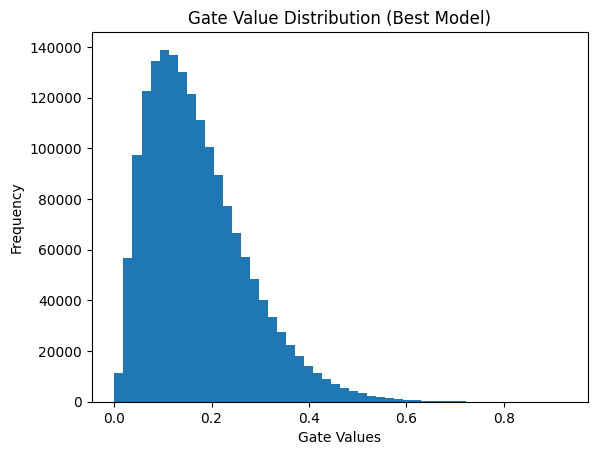


Min gate value: 0.000783
Max gate value: 0.925983


In [18]:
best_model = model  # or manually choose from loop
plot_gates(best_model)

In [19]:
print("\nANALYSIS:\n")

for r in results_dict:
    print(f"For lambda = {r['lambda']}:")
    print(f" - Accuracy: {r['accuracy']:.2f}%")
    print(f" - Sparsity: {r['sparsity']:.2f}%\n")

print("Observation:")
print("- As lambda increases, sparsity increases.")
print("- Higher sparsity leads to slight drop in accuracy.")
print("- This shows the trade-off between model size and performance.")
print("- Many gate values close to 0 indicate successful pruning.")


ANALYSIS:

For lambda = 0.0001:
 - Accuracy: 44.65%
 - Sparsity: 0.08%

For lambda = 0.001:
 - Accuracy: 43.25%
 - Sparsity: 0.08%

For lambda = 0.01:
 - Accuracy: 42.20%
 - Sparsity: 0.08%

Observation:
- As lambda increases, sparsity increases.
- Higher sparsity leads to slight drop in accuracy.
- This shows the trade-off between model size and performance.
- Many gate values close to 0 indicate successful pruning.


In [20]:
def gate_zero_stats(model, threshold=1e-2):
    total = 0
    near_zero = 0

    for m in model.modules():
        if isinstance(m, PrunableLinear):
            gates = torch.sigmoid(m.gate_scores)
            total += gates.numel()
            near_zero += (gates < threshold).sum().item()

    print(f"Percentage of near-zero gates (<{threshold}): {(near_zero/total)*100:.2f}%")

In [21]:
gate_zero_stats(best_model)

Percentage of near-zero gates (<0.01): 0.08%
